In [1]:
import os
import json
import time
import requests
import pandas as pd
import numpy as np
from datetime import datetime

In [2]:
COUNTRIES = ["USA", "DEU", "FRA", "IND", "CHN", "JPN", "GBR", "CAN", "AUS", "BRA"]

INDICATORS = {
    "NY.GDP.MKTP.CD": "gdp_current_usd",
    "SP.POP.TOTL": "population",
    "FP.CPI.TOTL.ZG": "inflation_percent",
    "SL.UEM.TOTL.ZS": "unemployment_percent",
    "EN.ATM.CO2E.PC": "co2_emissions_per_capita"
}

START_YEAR = 2014
END_YEAR = 2024

In [3]:
os.makedirs("../data/raw", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

print("Project setup ready.")

Project setup ready.


In [4]:
def fetch_world_bank_indicator(country, indicator, start_year, end_year):
    url = (
        f"https://api.worldbank.org/v2/country/{country}/indicator/{indicator}"
        f"?format=json&date={start_year}:{end_year}&per_page=100"
    )
    
    response = requests.get(url)
    
    if response.status_code == 200:
        data = response.json()
        if len(data) > 1:
            return data[1]
    
    return []

In [34]:
all_records = []

for country in COUNTRIES:
    for indicator_code, indicator_name in INDICATORS.items():
        print(f"Fetching {indicator_name} for {country}...")
        
        records = fetch_world_bank_indicator(
            country,
            indicator_code,
            START_YEAR,
            END_YEAR
        )
        
        for record in records:
            all_records.append({
                "country_code": country,
                "country_name": record["country"]["value"],
                "indicator_code": indicator_code,
                "indicator_name": indicator_name,
                "year": record["date"],
                "value": record["value"]
            })
        
        time.sleep(0.5)

print("Total records collected:", len(all_records))

Fetching gdp_current_usd for USA...
Fetching population for USA...
Fetching inflation_percent for USA...
Fetching unemployment_percent for USA...
Fetching co2_emissions_per_capita for USA...
Fetching gdp_current_usd for DEU...
Fetching population for DEU...
Fetching inflation_percent for DEU...
Fetching unemployment_percent for DEU...
Fetching co2_emissions_per_capita for DEU...
Fetching gdp_current_usd for FRA...
Fetching population for FRA...
Fetching inflation_percent for FRA...
Fetching unemployment_percent for FRA...
Fetching co2_emissions_per_capita for FRA...
Fetching gdp_current_usd for IND...
Fetching population for IND...
Fetching inflation_percent for IND...
Fetching unemployment_percent for IND...
Fetching co2_emissions_per_capita for IND...
Fetching gdp_current_usd for CHN...
Fetching population for CHN...
Fetching inflation_percent for CHN...
Fetching unemployment_percent for CHN...
Fetching co2_emissions_per_capita for CHN...
Fetching gdp_current_usd for JPN...
Fetching 

In [8]:
with open("../data/raw/world_bank_raw.json", "w", encoding="utf-8") as f:
    json.dump(all_records, f, indent=2)

print("Raw data saved.")

Raw data saved.


In [9]:
df_raw = pd.DataFrame(all_records)

df_raw.head()

,country_code,country_name,indicator_code,indicator_name,year,value
0,USA,United States,NY.GDP.MKTP.CD,gdp_current_usd,2024,2.875096e+13
1,USA,United States,NY.GDP.MKTP.CD,gdp_current_usd,2023,2.729217e+13
2,USA,United States,NY.GDP.MKTP.CD,gdp_current_usd,2022,2.560485e+13
3,USA,United States,NY.GDP.MKTP.CD,gdp_current_usd,2021,2.331508e+13
4,USA,United States,NY.GDP.MKTP.CD,gdp_current_usd,2020,2.106047e+13


In [10]:
df_raw.info()
df_raw.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country_code    440 non-null    str    
 1   country_name    440 non-null    str    
 2   indicator_code  440 non-null    str    
 3   indicator_name  440 non-null    str    
 4   year            440 non-null    str    
 5   value           440 non-null    float64
dtypes: float64(1), str(5)
memory usage: 39.4 KB


country_code      0
country_name      0
indicator_code    0
indicator_name    0
year              0
value             0
dtype: int64

In [11]:
df_clean = df_raw.copy()

df_clean["year"] = df_clean["year"].astype(int)
df_clean["value"] = pd.to_numeric(df_clean["value"], errors="coerce")

df_clean = df_clean.dropna(subset=["value"])

df_clean = df_clean.sort_values(
    by=["country_name", "indicator_name", "year"]
)

df_clean.head()

,country_code,country_name,indicator_code,indicator_name,year,value
362,AUS,Australia,NY.GDP.MKTP.CD,gdp_current_usd,2014,1.474677e+12
361,AUS,Australia,NY.GDP.MKTP.CD,gdp_current_usd,2015,1.356806e+12
360,AUS,Australia,NY.GDP.MKTP.CD,gdp_current_usd,2016,1.211588e+12
359,AUS,Australia,NY.GDP.MKTP.CD,gdp_current_usd,2017,1.330891e+12
358,AUS,Australia,NY.GDP.MKTP.CD,gdp_current_usd,2018,1.433145e+12


In [12]:
df_clean.to_csv("../data/processed/world_bank_clean.csv", index=False)

print("Cleaned data saved.")
print(df_clean.shape)

Cleaned data saved.
(440, 6)


In [13]:
df_final = df_clean.pivot_table(
    index=["country_code", "country_name", "year"],
    columns="indicator_name",
    values="value",
    aggfunc="first"
).reset_index()

df_final.head()

indicator_name,country_code,country_name,year,gdp_current_usd,inflation_percent,population,unemployment_percent
0,AUS,Australia,2014,1.474677e+12,2.487929,23475686.0,6.078
1,AUS,Australia,2015,1.356806e+12,1.508368,23815995.0,6.055
2,AUS,Australia,2016,1.211588e+12,1.276994,24190907.0,5.711
3,AUS,Australia,2017,1.330891e+12,1.948643,24592588.0,5.592
4,AUS,Australia,2018,1.433145e+12,1.911400,24963258.0,5.345


In [14]:
df_final.info()
df_final.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country_code          110 non-null    str    
 1   country_name          110 non-null    str    
 2   year                  110 non-null    int64  
 3   gdp_current_usd       110 non-null    float64
 4   inflation_percent     110 non-null    float64
 5   population            110 non-null    float64
 6   unemployment_percent  110 non-null    float64
dtypes: float64(4), int64(1), str(2)
memory usage: 7.3 KB


indicator_name
country_code            0
country_name            0
year                    0
gdp_current_usd         0
inflation_percent       0
population              0
unemployment_percent    0
dtype: int64

In [15]:
df_final.to_csv("../data/processed/global_economic_indicators.csv", index=False)

print("Final dataset saved.")
print(df_final.shape)
df_final.head()

Final dataset saved.
(110, 7)


indicator_name,country_code,country_name,year,gdp_current_usd,inflation_percent,population,unemployment_percent
0,AUS,Australia,2014,1.474677e+12,2.487929,23475686.0,6.078
1,AUS,Australia,2015,1.356806e+12,1.508368,23815995.0,6.055
2,AUS,Australia,2016,1.211588e+12,1.276994,24190907.0,5.711
3,AUS,Australia,2017,1.330891e+12,1.948643,24592588.0,5.592
4,AUS,Australia,2018,1.433145e+12,1.911400,24963258.0,5.345


In [17]:
latest_year = df_final["year"].max()
latest_year

np.int64(2024)

In [18]:
df_latest = df_final[df_final["year"] == latest_year].copy()

df_latest.sort_values("gdp_current_usd", ascending=False)

indicator_name,country_code,country_name,year,gdp_current_usd,inflation_percent,population,unemployment_percent
109,USA,United States,2024,2.875096e+13,2.949525,3.401110e+08,4.022
43,CHN,China,2024,1.874380e+13,0.218129,1.408975e+09,4.590
54,DEU,Germany,2024,4.685593e+12,2.256498,8.351659e+07,3.400
98,JPN,Japan,2024,4.027598e+12,2.738537,1.239754e+08,2.500
87,IND,India,2024,3.909892e+12,4.953036,1.450936e+09,4.173
76,GBR,United Kingdom,2024,3.686033e+12,3.271573,6.922600e+07,4.361
65,FRA,France,2024,3.160443e+12,1.999049,6.855165e+07,7.400
32,CAN,Canada,2024,2.243637e+12,2.381584,4.128860e+07,6.351
21,BRA,Brazil,2024,2.185822e+12,4.367464,2.119986e+08,6.801
10,AUS,Australia,2024,1.757022e+12,3.166567,2.719681e+07,3.942


In [19]:
# Country with highest GDP
df_latest.loc[df_latest["gdp_current_usd"].idxmax()]

indicator_name
country_code                              USA
country_name                    United States
year                                     2024
gdp_current_usd         28750956130731.199219
inflation_percent                    2.949525
population                        340110988.0
unemployment_percent                    4.022
Name: 109, dtype: object

In [20]:
# Country with highest population
df_latest.loc[df_latest["population"].idxmax()]

indicator_name
country_code                             IND
country_name                           India
year                                    2024
gdp_current_usd         3909891533858.080078
inflation_percent                   4.953036
population                      1450935791.0
unemployment_percent                   4.173
Name: 87, dtype: object

In [21]:
# Country with highest inflation
df_latest.loc[df_latest["inflation_percent"].idxmax()]

indicator_name
country_code                             IND
country_name                           India
year                                    2024
gdp_current_usd         3909891533858.080078
inflation_percent                   4.953036
population                      1450935791.0
unemployment_percent                   4.173
Name: 87, dtype: object

In [22]:
# Country with lowest unemployment
df_latest.loc[df_latest["unemployment_percent"].idxmin()]

indicator_name
country_code                             JPN
country_name                           Japan
year                                    2024
gdp_current_usd         4027597523550.580078
inflation_percent                   2.738537
population                       123975371.0
unemployment_percent                     2.5
Name: 98, dtype: object

In [23]:
df_latest.to_csv("../data/processed/latest_economic_indicators.csv", index=False)

print("Latest year dataset saved:", latest_year)

Latest year dataset saved: 2024


In [25]:
conn = psycopg2.connect(
    dbname="GlobalEconomy",
    user="global_user",
    password="admin123",
    host="localhost",
    port="5432"
)

cur = conn.cursor()
print("Connected successfully.")

Connected successfully.


In [26]:
insert_query = """
INSERT INTO economic_indicators (
    country_code,
    country_name,
    year,
    co2_emissions_per_capita,
    gdp_current_usd,
    inflation_percent,
    population,
    unemployment_percent
)
VALUES (%s, %s, %s, %s, %s, %s, %s, %s)
"""

for _, row in df_final.iterrows():
    cur.execute(insert_query, (
        row["country_code"],
        row["country_name"],
        int(row["year"]),
        row.get("co2_emissions_per_capita"),
        row.get("gdp_current_usd"),
        row.get("inflation_percent"),
        row.get("population"),
        row.get("unemployment_percent")
    ))

conn.commit()

print("Data inserted successfully.")

Data inserted successfully.


In [27]:
cur.execute("SELECT COUNT(*) FROM economic_indicators;")
cur.fetchone()

(110,)

In [28]:
from pymongo import MongoClient

client = MongoClient("mongodb://localhost:27017/")

mongo_db = client["global_economy"]
profiles_collection = mongo_db["country_profiles"]

print("MongoDB connected.")

MongoDB connected.


In [29]:
country_profiles = []

for country in df_final["country_name"].unique():
    country_data = df_final[df_final["country_name"] == country]
    latest_row = country_data[country_data["year"] == country_data["year"].max()].iloc[0]
    
    country_profiles.append({
        "country_code": latest_row["country_code"],
        "country_name": latest_row["country_name"],
        "latest_year": int(latest_row["year"]),
        "latest_gdp_current_usd": float(latest_row["gdp_current_usd"]),
        "latest_population": float(latest_row["population"]),
        "latest_inflation_percent": None if pd.isna(latest_row["inflation_percent"]) else float(latest_row["inflation_percent"]),
        "latest_unemployment_percent": None if pd.isna(latest_row["unemployment_percent"]) else float(latest_row["unemployment_percent"]),
        "business_category": "Global economic monitoring"
    })

profiles_collection.delete_many({})
profiles_collection.insert_many(country_profiles)

print("Inserted profiles:", profiles_collection.count_documents({}))

Inserted profiles: 10


In [30]:
for doc in profiles_collection.find().limit(5):
    print(doc)

{'_id': ObjectId('6a31cd3cc07b97a3d3deaea6'), 'country_code': 'AUS', 'country_name': 'Australia', 'latest_year': 2024, 'latest_gdp_current_usd': 1757022451652.83, 'latest_population': 27196812.0, 'latest_inflation_percent': 3.16656665428797, 'latest_unemployment_percent': 3.942, 'business_category': 'Global economic monitoring'}
{'_id': ObjectId('6a31cd3cc07b97a3d3deaea7'), 'country_code': 'BRA', 'country_name': 'Brazil', 'latest_year': 2024, 'latest_gdp_current_usd': 2185821648943.86, 'latest_population': 211998573.0, 'latest_inflation_percent': 4.36746407652336, 'latest_unemployment_percent': 6.801, 'business_category': 'Global economic monitoring'}
{'_id': ObjectId('6a31cd3cc07b97a3d3deaea8'), 'country_code': 'CAN', 'country_name': 'Canada', 'latest_year': 2024, 'latest_gdp_current_usd': 2243636826633.76, 'latest_population': 41288599.0, 'latest_inflation_percent': 2.38158383281173, 'latest_unemployment_percent': 6.351, 'business_category': 'Global economic monitoring'}
{'_id': Obje

In [31]:
print("Total profiles:", profiles_collection.count_documents({}))

Total profiles: 10


In [32]:
for doc in profiles_collection.find(
    {"latest_gdp_current_usd": {"$gt": 1000000000000}}
):
    print(
        doc["country_name"],
        "-",
        round(doc["latest_gdp_current_usd"]/1e12, 2),
        "Trillion USD"
    )

Australia - 1.76 Trillion USD
Brazil - 2.19 Trillion USD
Canada - 2.24 Trillion USD
China - 18.74 Trillion USD
Germany - 4.69 Trillion USD
France - 3.16 Trillion USD
United Kingdom - 3.69 Trillion USD
India - 3.91 Trillion USD
Japan - 4.03 Trillion USD
United States - 28.75 Trillion USD


In [33]:
for doc in profiles_collection.find(
    {"latest_population": {"$gt": 100000000}}
):
    print(
        doc["country_name"],
        "-",
        int(doc["latest_population"])
    )

Brazil - 211998573
China - 1408975000
India - 1450935791
Japan - 123975371
United States - 340110988


In [34]:
highest_gdp = profiles_collection.find_one(
    sort=[("latest_gdp_current_usd", -1)]
)

print(highest_gdp["country_name"])

United States


In [28]:
from sklearn.linear_model import LinearRegression

print("Scikit-learn working")

Scikit-learn working


In [29]:
usa_df = df_final[
    df_final["country_code"] == "USA"
][["year", "gdp_current_usd"]].copy()

print(usa_df.shape)

usa_df.head()

(11, 2)


indicator_name,year,gdp_current_usd
99,2014,1.755068e+13
100,2015,1.820602e+13
101,2016,1.869511e+13
102,2017,1.947734e+13
103,2018,2.053306e+13


In [30]:
X = usa_df[["year"]]
y = usa_df["gdp_current_usd"]

model = LinearRegression()
model.fit(X, y)

print("GDP prediction model trained successfully.")

GDP prediction model trained successfully.


In [31]:
future_years = pd.DataFrame({"year": [2025, 2026, 2027]})

future_years["predicted_gdp"] = model.predict(
    future_years[["year"]]
)

future_years

,year,predicted_gdp
0,2025,2.860305e+13
1,2026,2.970558e+13
2,2027,3.080811e+13


Matplotlib is building the font cache; this may take a moment.


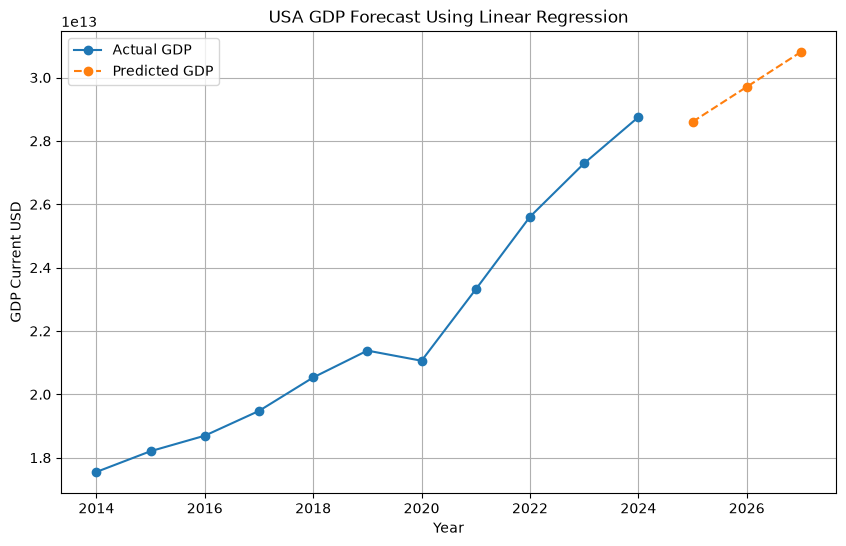

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    usa_df["year"],
    usa_df["gdp_current_usd"],
    marker="o",
    label="Actual GDP"
)

plt.plot(
    future_years["year"],
    future_years["predicted_gdp"],
    marker="o",
    linestyle="--",
    label="Predicted GDP"
)

plt.title("USA GDP Forecast Using Linear Regression")
plt.xlabel("Year")
plt.ylabel("GDP Current USD")
plt.legend()
plt.grid(True)

plt.show()

In [33]:
future_years.to_csv("../data/processed/usa_gdp_predictions.csv", index=False)

print("GDP predictions saved.")

GDP predictions saved.
